# Dekad combination

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar
import ocha_stratus as stratus
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.special import expit  # logistic function


from src.constants import *

In [3]:
blob_name = f"{PROJECT_PREFIX}/processed/iri_cerf_stats.parquet"
df_stats_iri = stratus.load_parquet_from_blob(blob_name)

In [34]:
df_stats_iri

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,0.0,NaN
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,0.0,NaN
2,1993,32.6,37.6,33.9,37.2,38.3,47.5,16.0,None,70.4,0.0,NaN
3,1994,32.3,32.8,35.3,42.0,43.8,39.4,16.0,None,80.7,0.0,NaN
4,1995,33.7,31.6,24.5,30.8,31.3,27.2,16.0,None,91.1,0.0,NaN
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,0.0,NaN
6,1997,34.2,39.6,42.4,28.9,36.1,41.3,16.0,None,71.2,0.0,NaN
7,1998,32.8,26.8,33.0,25.8,30.6,27.5,16.0,None,85.0,0.0,NaN
8,1999,36.3,31.3,35.8,40.3,27.5,25.7,30.0,None,99.1,0.0,NaN
9,2000,36.1,32.9,32.5,27.7,35.4,28.0,16.0,None,76.7,0.0,NaN


In [35]:
df_stats_iri_full = df_stats_iri[df_stats_iri["year"] < 2025]

In [36]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/chirps/chirps_dek_season_cumul.parquet"
)
df_chirps_raw = stratus.load_parquet_from_blob(blob_name)

In [37]:
df_chirps_raw

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall
0,1981-07-01,6.217109,26.439596,1981,6.217109,26.439596,1,19
1,1981-07-11,4.196940,14.369387,1981,10.414049,40.808983,2,20
2,1981-07-21,13.793546,50.955724,1981,24.207595,91.764707,3,21
3,1981-08-01,8.613187,38.008222,1981,32.820782,129.772929,1,22
4,1981-08-11,6.975212,17.575585,1981,39.795994,147.348513,2,23
...,...,...,...,...,...,...,...,...
400,2025-08-11,14.622507,37.223278,2025,38.626457,118.941812,2,23
401,2025-08-21,6.727946,26.086023,2025,45.354403,145.027834,3,24
402,2025-09-01,11.359299,39.957623,2025,56.713702,184.985458,1,25
403,2025-09-11,6.046738,4.695130,2025,62.760440,189.680587,2,26


In [82]:
df_dek = df_chirps_raw[
    (df_chirps_raw["year"] < 2025) & (df_chirps_raw["year"] >= 1991)
].copy()

In [83]:
df_chirps_final = df_chirps_raw[df_chirps_raw["dekad_overall"] == 27]

In [84]:
df_stats_iri_full = df_stats_iri_full.merge(
    df_chirps_final[["year", "rfh_all_cumul", "rfh_aoi_cumul"]]
)

<Axes: xlabel='CHIRPS Precip JAS (mm)'>

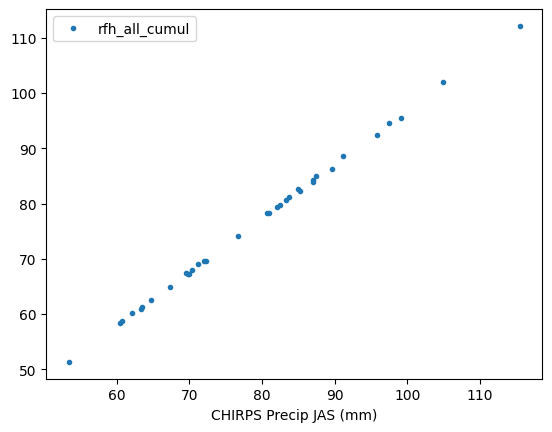

In [85]:
df_stats_iri_full.plot(
    x="CHIRPS Precip JAS (mm)", y="rfh_all_cumul", linewidth=0, marker="."
)

In [86]:
df_stats_iri_full.corr(numeric_only=True, method="spearman")["rfh_all_cumul"][
    "CHIRPS Precip JAS (mm)"
]

np.float64(0.9983956022720397)

In [87]:
for col in ["rfh_all_cumul", "CHIRPS Precip JAS (mm)"]:
    df_stats_iri_full[f"{col}_rank"] = df_stats_iri_full[col].rank(
        ascending=True
    )

In [88]:
df_stats_iri_full.sort_values("rfh_all_cumul_rank")

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$,rfh_all_cumul,rfh_aoi_cumul,rfh_all_cumul_rank,CHIRPS Precip JAS (mm)_rank
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,0.0,NaN,51.311365,166.521189,1.0,1.0
11,2002,32.4,34.3,40.5,34.2,38.1,35.1,7.0,None,60.4,0.0,NaN,58.278898,197.796330,2.0,2.0
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,0.0,NaN,58.703547,190.209995,3.0,3.0
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,0.0,NaN,60.121881,210.054397,4.0,4.0
28,2019,22.7,28.4,32.4,33.0,30.2,32.8,8.0,None,63.3,0.0,0.0,60.968869,174.521821,5.0,5.0
20,2011,36.5,35.9,26.9,41.0,35.0,27.5,2.0,Bad,63.5,1.0,4005971.0,61.178384,194.645161,6.0,6.0
26,2017,30.7,39.1,35.4,35.9,31.8,24.8,6.0,None,64.7,0.0,3975873.0,62.546641,206.154328,7.0,7.0
23,2014,30.8,35.3,42.2,40.8,39.2,29.7,4.0,None,67.3,0.0,2532163.0,64.870469,256.714735,8.0,8.0
13,2004,32.8,29.3,34.5,33.9,35.4,34.2,16.0,None,69.8,0.0,NaN,67.242343,261.750161,9.0,10.0
30,2021,20.9,14.9,18.3,19.6,18.7,21.2,10.0,None,70.0,0.0,0.0,67.317151,239.623656,10.0,11.0


<Axes: xlabel='year'>

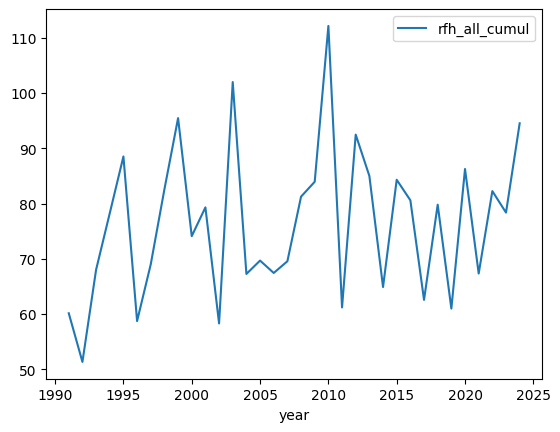

In [89]:
df_stats_iri_full.plot(x="year", y="rfh_all_cumul")

In [90]:
n_total_years = df_dek["year"].nunique()
rp_overall_target = 7
n_years_overall_target = int((n_total_years + 1) / rp_overall_target)

In [91]:
n_years_overall_target

5

In [92]:
df_stats_iri = df_stats_iri.merge(
    df_chirps_final[["year", "rfh_all_cumul", "rfh_aoi_cumul"]]
)

In [93]:
col = "rfh_all_cumul"

df_stats_iri["obsv_target"] = (
    df_stats_iri[col]
    <= df_stats_iri[col].nsmallest(n_years_overall_target).max()
)

In [94]:
df_stats_iri_full

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$,rfh_all_cumul,rfh_aoi_cumul,rfh_all_cumul_rank,CHIRPS Precip JAS (mm)_rank
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,0.0,NaN,60.121881,210.054397,4.0,4.0
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,0.0,NaN,51.311365,166.521189,1.0,1.0
2,1993,32.6,37.6,33.9,37.2,38.3,47.5,16.0,None,70.4,0.0,NaN,68.003672,188.646425,12.0,12.0
3,1994,32.3,32.8,35.3,42.0,43.8,39.4,16.0,None,80.7,0.0,NaN,78.242482,236.755851,17.0,17.0
4,1995,33.7,31.6,24.5,30.8,31.3,27.2,16.0,None,91.1,0.0,NaN,88.517791,273.407340,29.0,29.0
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,0.0,NaN,58.703547,190.209995,3.0,3.0
6,1997,34.2,39.6,42.4,28.9,36.1,41.3,16.0,None,71.2,0.0,NaN,68.987787,199.148639,13.0,13.0
7,1998,32.8,26.8,33.0,25.8,30.6,27.5,16.0,None,85.0,0.0,NaN,82.569926,239.673621,24.0,23.0
8,1999,36.3,31.3,35.8,40.3,27.5,25.7,30.0,None,99.1,0.0,NaN,95.462707,333.540164,32.0,32.0
9,2000,36.1,32.9,32.5,27.7,35.4,28.0,16.0,None,76.7,0.0,NaN,74.087495,278.465525,16.0,16.0


In [95]:
df_dek = df_dek.merge(df_stats_iri[["year", "obsv_target"]], how="left")

In [97]:
dicts = []
for dekad, group in df_dek.groupby("dekad_overall"):
    for _trig_years in range(n_years_overall_target, -1, -1):
        _thresh = (
            group[col].nsmallest(_trig_years).max()
            + group[col].nsmallest(_trig_years + 1).max()
        ) / 2
        group["_trigger"] = group[col] <= _thresh
        fp = group["_trigger"] & ~group["obsv_target"]
        if not fp.any():
            df_stats_iri[f"d{dekad}_trig"] = df_stats_iri["year"].isin(
                group[group["_trigger"]]["year"].unique()
            )
            dicts.append(
                {"dekad": dekad, "thresh": _thresh, "n_years": _trig_years}
            )
            break

df_threshs = pd.DataFrame(dicts)

In [98]:
df_threshs

,dekad,thresh,n_years
0,19,NaN,0
1,20,6.029670,2
2,21,9.886243,1
3,22,17.781360,2
4,23,28.776061,3
5,24,41.703811,3
6,25,47.855195,3
7,26,53.117207,2
8,27,61.073626,5


In [99]:
def highlight_true(val):
    if isinstance(val, bool) and val is True:
        return "background-color: crimson"
    return ""

In [100]:
cols = [f"d{x}_trig" for x in range(19, 28)]

In [101]:
df_stats_iri.set_index("year")[cols].style.map(highlight_true)

,d19_trig,d20_trig,d21_trig,d22_trig,d23_trig,d24_trig,d25_trig,d26_trig,d27_trig
year,,,,,,,,,
1991,False,False,False,False,False,False,False,False,True
1992,False,False,False,False,True,True,True,True,True
1993,False,False,False,False,False,False,False,False,False
1994,False,False,False,False,False,False,False,False,False
1995,False,False,False,False,False,False,False,False,False
1996,False,False,False,False,False,False,True,False,True
1997,False,False,False,False,False,False,False,False,False
1998,False,False,False,False,False,False,False,False,False
1999,False,False,False,False,False,False,False,False,False


<Axes: >

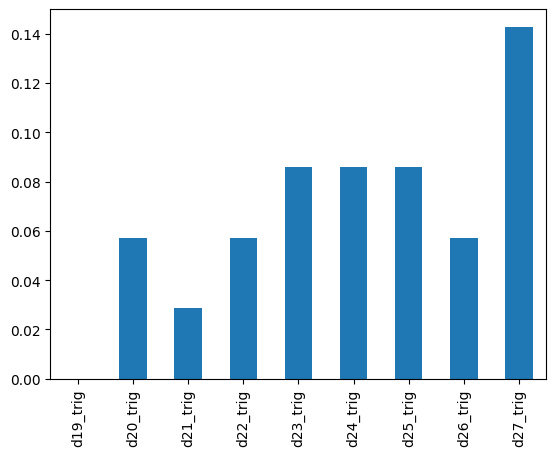

In [102]:
df_stats_iri.set_index("year")[cols].mean().plot.bar()

In [107]:
df_dek = df_dek.merge(
    df_threshs.rename(columns={"dekad": "dekad_overall"}), how="left"
)

In [108]:
df_dek["obsv_trig"] = df_dek["rfh_all_cumul"] <= df_dek["thresh"]

In [109]:
df_dek[df_dek["dekad_overall"] == 27].sort_values("rfh_all_cumul")

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall,obsv_target,thresh,n_years,obsv_trig
17,1992-09-21,2.871721,10.199241,1992,51.311365,166.521189,3,27,True,61.073626,5,True
107,2002-09-21,6.587397,13.595193,2002,58.278898,197.796330,3,27,True,61.073626,5,True
53,1996-09-21,4.115955,18.273877,1996,58.703547,190.209995,3,27,True,61.073626,5,True
8,1991-09-21,4.588427,13.232764,1991,60.121881,210.054397,3,27,True,61.073626,5,True
260,2019-09-21,5.632800,16.846300,2019,60.968869,174.521821,3,27,True,61.073626,5,True
188,2011-09-21,5.701405,35.481973,2011,61.178384,194.645161,3,27,False,61.073626,5,False
242,2017-09-21,8.003728,23.851360,2017,62.546641,206.154328,3,27,False,61.073626,5,False
215,2014-09-21,5.446877,28.088552,2014,64.870469,256.714735,3,27,False,61.073626,5,False
125,2004-09-21,3.601224,11.997470,2004,67.242343,261.750161,3,27,False,61.073626,5,False
278,2021-09-21,3.371929,7.050601,2021,67.317151,239.623656,3,27,False,61.073626,5,False


[None, None]

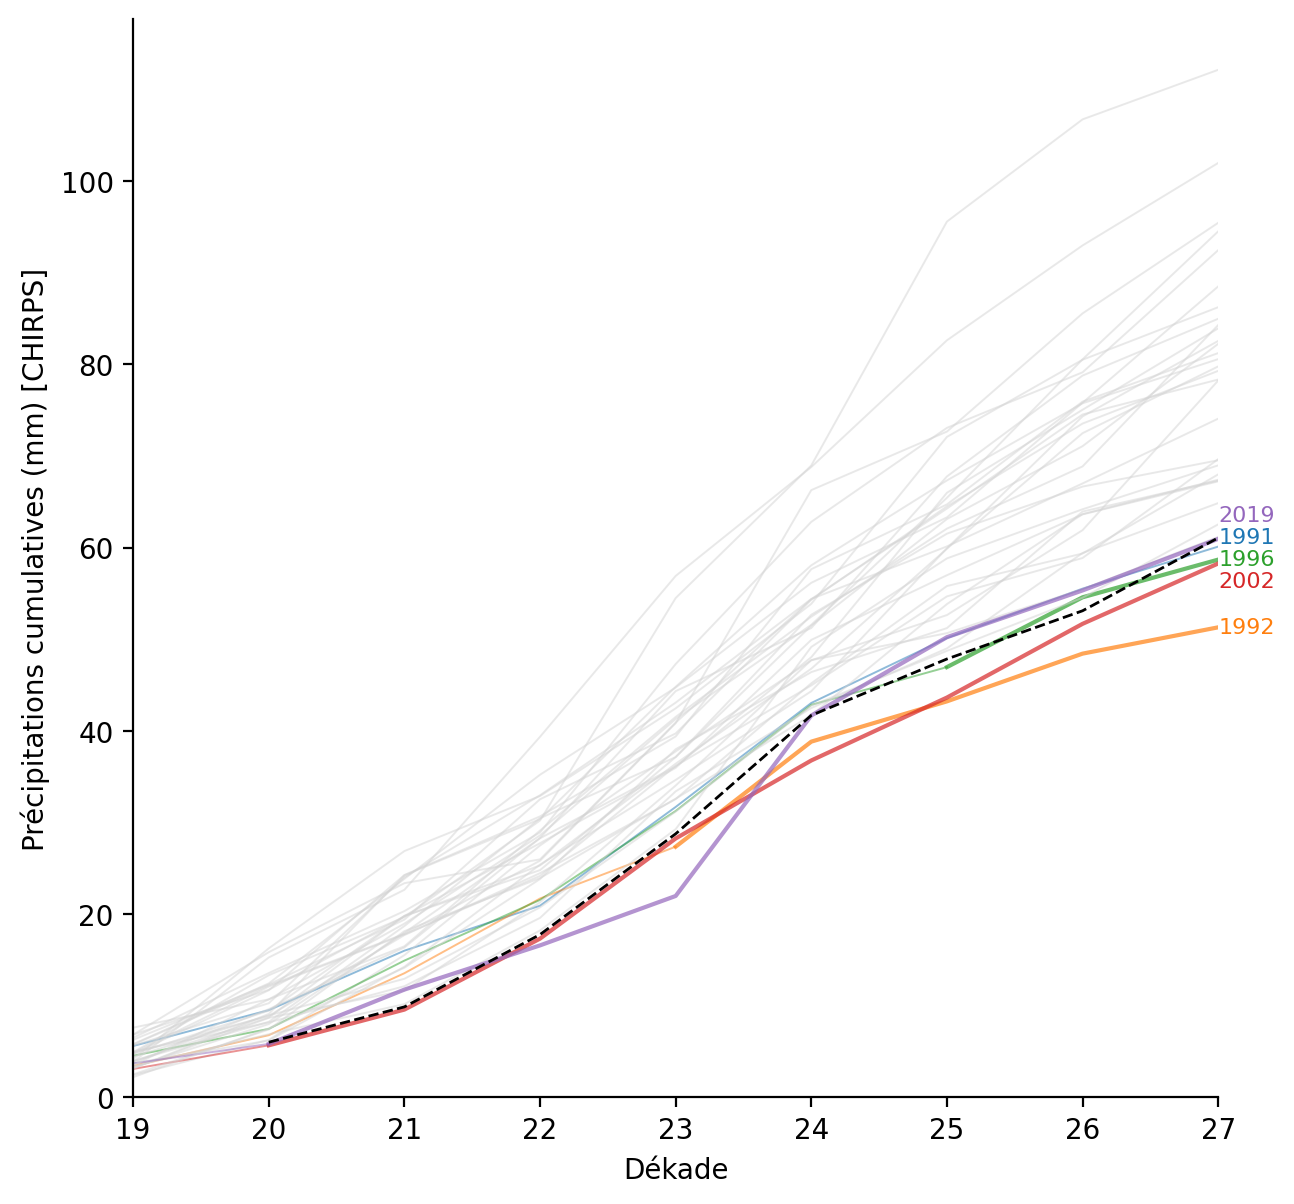

In [110]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

col = "rfh_all_cumul"

cmap = plt.cm.tab10
color_idx = 0

year_colors = {}  # store colors for triggered years

for year, group in df_dek.groupby("year"):

    first_dek_trig = group[group["obsv_trig"]]["dekad_overall"].min()
    any_trig = group["obsv_trig"].any()

    if any_trig:
        color = cmap(color_idx % cmap.N)
        year_colors[year] = color
        color_idx += 1
    else:
        color = "lightgrey"

    if any_trig:
        group_trig = group[group["dekad_overall"] >= first_dek_trig]
        group_notrig = group[group["dekad_overall"] <= first_dek_trig]
    else:
        group_trig = group.iloc[0:0]
        group_notrig = group

    if len(group_trig):
        group_trig.plot(
            x="dekad_overall",
            y=col,
            ax=ax,
            color=color,
            alpha=0.7,
            linewidth=1.5,
        )

    group_notrig.plot(
        x="dekad_overall",
        y=col,
        ax=ax,
        color=color,
        alpha=0.5,
        linewidth=0.7,
    )

df_threshs.plot(
    x="dekad",
    y="thresh",
    ax=ax,
    color="k",
    linewidth=1,
    linestyle="--",
)

# ---- annotate years on right edge ----

x_text = 27  # slightly beyond axis limit

y_adj = {
    2019: 2.5,
    1991: 1,
    1996: 0,
    2002: -2,
}

for year, color in year_colors.items():
    group = df_dek[df_dek["year"] == year]

    # get last dekad value within plotting window
    last_row = group[group["dekad_overall"] == 27]

    if not last_row.empty:
        y_val = last_row[col].values[0]
        ax.text(
            x_text,
            y_val + y_adj.get(year, 0),
            str(year),
            color=color,
            fontsize=8,
            va="center",
        )

# formatting
ax.set_xlabel("Dékade")
ax.set_ylabel("Précipitations cumulatives (mm) [CHIRPS]")
ax.set_xlim((19, 27))  # extend slightly for labels
ax.set_ylim(bottom=0)

ax.legend().set_visible(False)

[ax.spines[x].set_visible(False) for x in ["top", "right"]]